# TP2 - Medición de foco

Se trabaja con el video focus_video.mov para detectar en qué frame aparece el mayor enfoque

Para esto se usa una métrica basada en Fourier, se calcula primero sobre todo el frame y luego sobre una ROI ubicada en el centro de la imagen

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)

In [19]:
video_path = Path("focus_video.mov")

In [20]:
cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    print("no se pudo abrir el video")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("Total de frames:", total_frames)
    print("FPS:", fps)
    print("Resolución:", ancho, "x", alto)

cap.release()

Total de frames: 171
FPS: 29.97002997002997
Resolución: 640 x 360


Frame leído: True


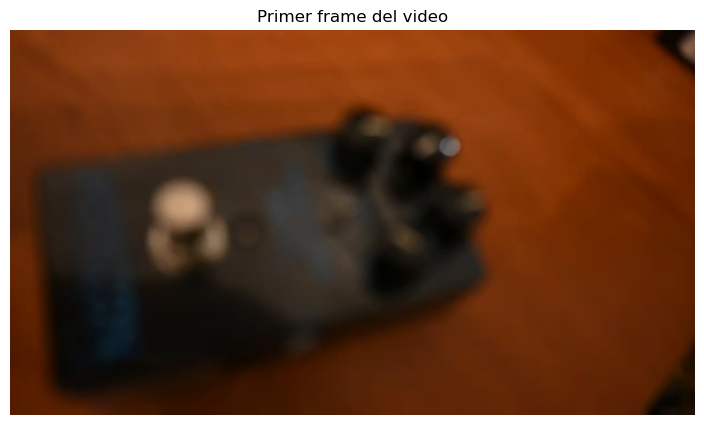

In [21]:
cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()
cap.release()

print("Frame leído:", ret)
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.title("Primer frame del video")
    plt.axis("off")
    plt.show()

In [22]:
def focus_measure_frequency(img_gray):
    """
    Calcula una metrica de enfoque en el dominio de la frecuencia se aplica FFT 2D, se centra el espectro, se calcula la magnitud
    y se cuenta cuántos valores superan un umbral definido como max/1000
    """

    img_float = img_gray.astype(np.float32)

    F = np.fft.fft2(img_float)
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)
    max_value = np.max(AF)

    if max_value == 0:
        return 0
    threshold = max_value / 1000.0
    TH = np.sum(AF > threshold)
    FM = TH / AF.size

    return FM

## Métrica usada

La idea es que una imagen más enfocada tiene más detalles y bordes, por lo tanto tiene más componentes de alta frecuencia.

Para cada frame se calcula la FFT, se toma la magnitud del espectro y se cuenta cuántos valores superan un umbral. El frame con el valor más alto se toma como el de mayor enfoque.

## Experimento 1: medición de foco sobre todo el frame

Se calcula la métrica de enfoque sobre cada frame completo del video

In [23]:
cap = cv2.VideoCapture(str(video_path))

focus_full = []
frames_idx = []
frame_number = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fm = focus_measure_frequency(gray)
    focus_full.append(fm)
    frames_idx.append(frame_number)
    frame_number += 1

cap.release()

focus_full = np.array(focus_full)
frames_idx = np.array(frames_idx)

print("Frames procesados:", len(focus_full))
print("Frame con mayor enfoque:", np.argmax(focus_full))
print("Valor máximo de enfoque:", np.max(focus_full))

Frames procesados: 171
Frame con mayor enfoque: 109
Valor máximo de enfoque: 0.028624131944444443


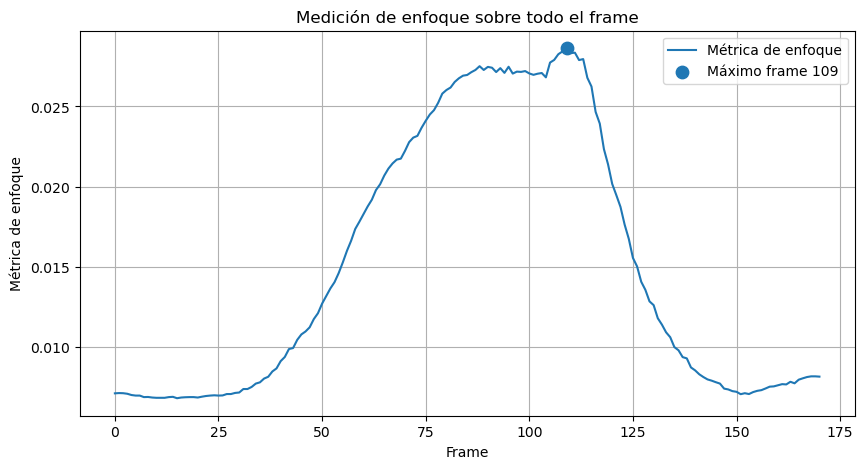

In [24]:
max_full_idx = np.argmax(focus_full)
max_full_value = focus_full[max_full_idx]

plt.figure(figsize=(10, 5))
plt.plot(frames_idx, focus_full, label="Métrica de enfoque")
plt.scatter(max_full_idx, max_full_value, s=80, label=f"Máximo frame {max_full_idx}")
plt.title("Medición de enfoque sobre todo el frame")
plt.xlabel("Frame")
plt.ylabel("Métrica de enfoque")
plt.grid()
plt.legend()
plt.show()

## Experimento 2: medición de foco sobre una ROI central

Se toma una región de interés ubicada en el centro del frame. Se eligió una ROI con área equivalente al 10% del área total del frame.

In [25]:
def get_center_roi(img_gray, area_ratio=0.10):
    """
    Devuelve una ROI centrada cuya area es un porcentaje del area total de la imagen
    """
    h, w = img_gray.shape
    scale = np.sqrt(area_ratio)

    roi_w = int(w * scale)
    roi_h = int(h * scale)

    x1 = (w - roi_w) // 2
    y1 = (h - roi_h) // 2

    x2 = x1 + roi_w
    y2 = y1 + roi_h
    roi = img_gray[y1:y2, x1:x2]

    return roi, (x1, y1, x2, y2)

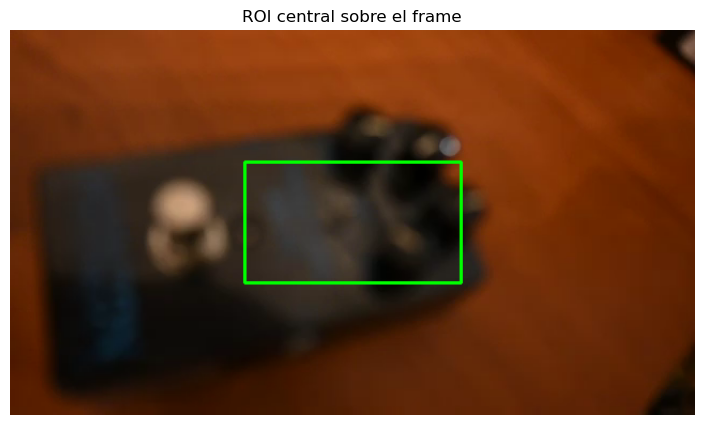

Coordenadas ROI: 219 123 421 236
Área ROI: 22826
Área total: 230400


In [26]:
cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()
cap.release()

if ret:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi, (x1, y1, x2, y2) = get_center_roi(gray, area_ratio=0.10)

    frame_roi = frame.copy()
    cv2.rectangle(frame_roi, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(frame_roi, cv2.COLOR_BGR2RGB))
    plt.title("ROI central sobre el frame")
    plt.axis("off")
    plt.show()

    print("Coordenadas ROI:", x1, y1, x2, y2)
    print("Área ROI:", roi.shape[0] * roi.shape[1])
    print("Área total:", gray.shape[0] * gray.shape[1])

In [27]:
cap = cv2.VideoCapture(str(video_path))

focus_roi = []
frames_idx = []

frame_number = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi, _ = get_center_roi(gray, area_ratio=0.10)
    fm = focus_measure_frequency(roi)
    focus_roi.append(fm)
    frames_idx.append(frame_number)
    frame_number += 1

cap.release()
focus_roi = np.array(focus_roi)
frames_idx = np.array(frames_idx)

print("Frames procesados:", len(focus_roi))
print("Frame con mayor enfoque en ROI:", np.argmax(focus_roi))
print("Valor máximo de enfoque en ROI:", np.max(focus_roi))

Frames procesados: 171
Frame con mayor enfoque en ROI: 111
Valor máximo de enfoque en ROI: 0.35770612459476037


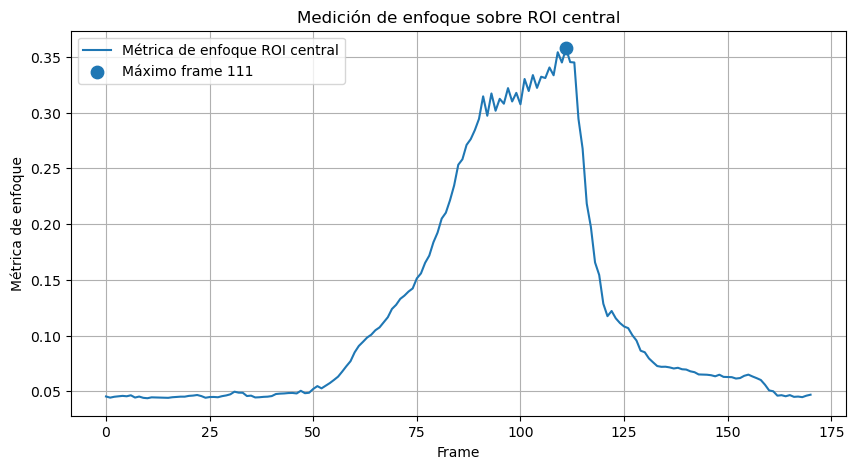

In [28]:
max_roi_idx = np.argmax(focus_roi)
max_roi_value = focus_roi[max_roi_idx]

plt.figure(figsize=(10, 5))
plt.plot(frames_idx, focus_roi, label="Métrica de enfoque ROI central")
plt.scatter(max_roi_idx, max_roi_value, s=80, label=f"Máximo frame {max_roi_idx}")
plt.title("Medición de enfoque sobre ROI central")
plt.xlabel("Frame")
plt.ylabel("Métrica de enfoque")
plt.grid()
plt.legend()
plt.show()

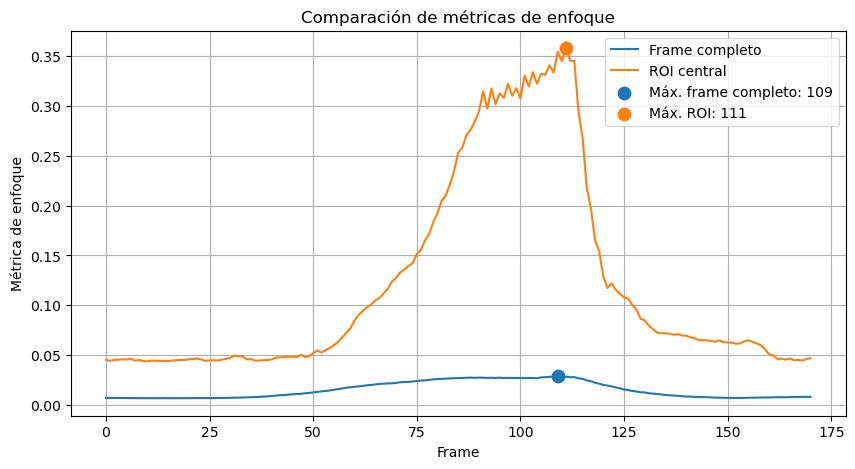

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(frames_idx, focus_full, label="Frame completo")
plt.plot(frames_idx, focus_roi, label="ROI central")
plt.scatter(max_full_idx, focus_full[max_full_idx], s=80, label=f"Máx. frame completo: {max_full_idx}")
plt.scatter(max_roi_idx, focus_roi[max_roi_idx], s=80, label=f"Máx. ROI: {max_roi_idx}")
plt.title("Comparación de métricas de enfoque")
plt.xlabel("Frame")
plt.ylabel("Métrica de enfoque")
plt.grid()
plt.legend()
plt.show()

In [30]:
def get_frame(video_path, frame_number):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    ret, frame = cap.read()
    cap.release()

    if ret:
        return frame
    else:
        return None

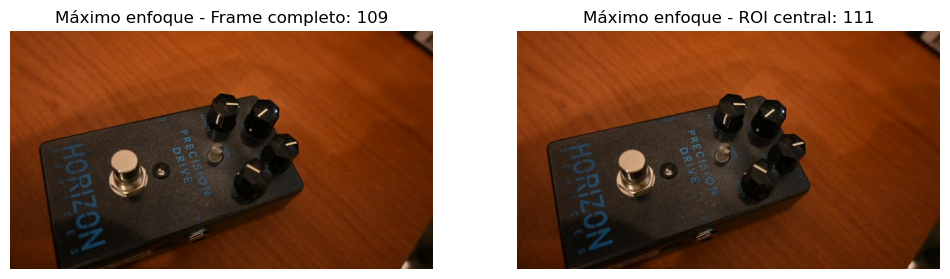

In [31]:
frame_max_full = get_frame(video_path, max_full_idx)
frame_max_roi = get_frame(video_path, max_roi_idx)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame_max_full, cv2.COLOR_BGR2RGB))
plt.title(f"Máximo enfoque - Frame completo: {max_full_idx}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(frame_max_roi, cv2.COLOR_BGR2RGB))
plt.title(f"Máximo enfoque - ROI central: {max_roi_idx}")
plt.axis("off")

plt.show()

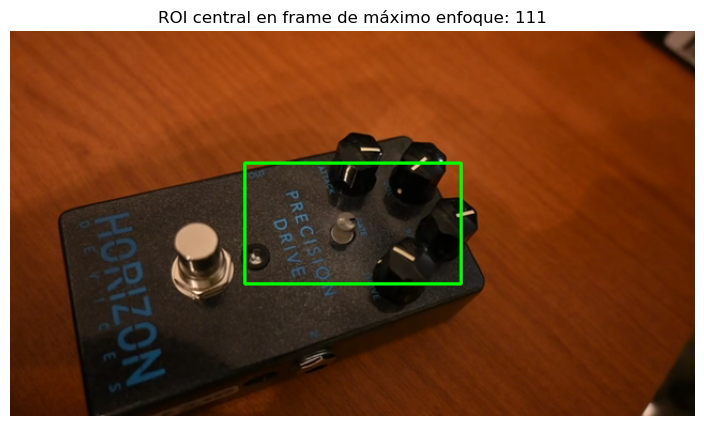

In [32]:
frame_roi_max = frame_max_roi.copy()
gray_roi_max = cv2.cvtColor(frame_roi_max, cv2.COLOR_BGR2GRAY)
_, (x1, y1, x2, y2) = get_center_roi(gray_roi_max, area_ratio=0.10)
cv2.rectangle(frame_roi_max, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(frame_roi_max, cv2.COLOR_BGR2RGB))
plt.title(f"ROI central en frame de máximo enfoque: {max_roi_idx}")
plt.axis("off")
plt.show()

## Experimento 3: matriz de enfoque

Como última prueba se toma el frame donde se detectó el mayor enfoque y se divide en una grilla, luego se calcula la métrica de enfoque en cada bloque para ver qué zona del frame tiene mayor detalle

In [33]:
def focus_grid_on_frame(frame, rows=7, cols=7):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    cell_h = h // rows
    cell_w = w // cols
    focus_map = np.zeros((rows, cols))
    frame_grid = frame.copy()
    for i in range(rows):
        for j in range(cols):
            y1 = i * cell_h
            y2 = (i + 1) * cell_h if i < rows - 1 else h

            x1 = j * cell_w
            x2 = (j + 1) * cell_w if j < cols - 1 else w
            roi = gray[y1:y2, x1:x2]
            focus_map[i, j] = focus_measure_frequency(roi)
            cv2.rectangle(frame_grid, (x1, y1), (x2, y2), (0, 255, 0), 1)

    max_pos = np.unravel_index(np.argmax(focus_map), focus_map.shape)
    i, j = max_pos
    y1 = i * cell_h
    y2 = (i + 1) * cell_h if i < rows - 1 else h
    x1 = j * cell_w
    x2 = (j + 1) * cell_w if j < cols - 1 else w
    cv2.rectangle(frame_grid, (x1, y1), (x2, y2), (0, 0, 255), 3)

    return focus_map, frame_grid, max_pos

In [34]:
frame_exp3 = get_frame(video_path, max_full_idx)

focus_map, frame_grid, max_pos = focus_grid_on_frame(frame_exp3, rows=7, cols=7)
print("Frame usado:", max_full_idx)
print("Bloque con mayor enfoque:", max_pos)
print("Valor máximo:", focus_map[max_pos])

Frame usado: 109
Bloque con mayor enfoque: (np.int64(2), np.int64(3))
Valor máximo: 0.6621417797888386


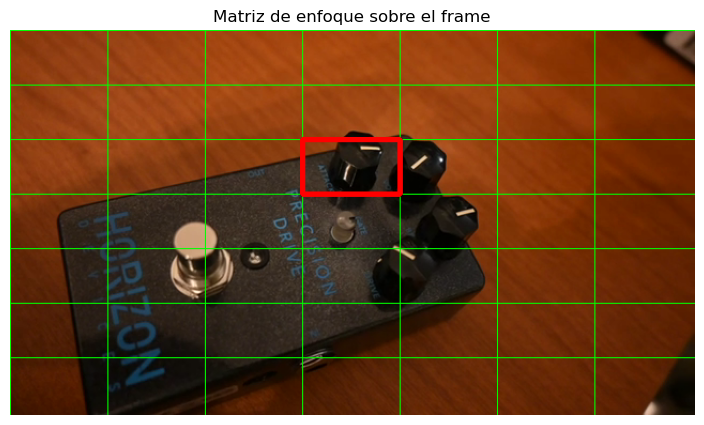

In [35]:
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(frame_grid, cv2.COLOR_BGR2RGB))
plt.title("Matriz de enfoque sobre el frame")
plt.axis("off")
plt.show()

In [36]:
np.set_printoptions(precision=3, suppress=True)
print(focus_map)

[[0.036 0.031 0.025 0.027 0.026 0.04  0.168]
 [0.041 0.043 0.039 0.181 0.08  0.04  0.047]
 [0.061 0.114 0.262 0.662 0.468 0.048 0.046]
 [0.248 0.398 0.552 0.608 0.563 0.067 0.044]
 [0.218 0.514 0.573 0.621 0.582 0.042 0.046]
 [0.217 0.344 0.295 0.569 0.203 0.053 0.082]
 [0.222 0.4   0.464 0.419 0.078 0.071 0.248]]


## Análisis

Con la medición sobre todo el frame, el máximo enfoque se detectó en el frame 109, al medir solo la ROI central, el máximo se detectó en el frame 111

Los dos resultados son cercanos por lo que el método está detectando la misma zona de enfoque del video, la ROI central da valores más altos porque se concentra en la parte de la imagen donde hay más detalle del objeto

En general la métrica permite encontrar automáticamente el punto de mayor enfoque, la diferencia entre medir todo el frame y medir una ROI es que el frame completo también toma en cuenta zonas del fondo, mientras que la ROI se enfoca más en el objeto central

También se hizo una matriz de enfoque dividiendo el frame en una grilla, en cada bloque se calculó la misma métrica y se marcó el bloque con mayor valor permitiendo ver de forma simple qué zona del frame tenía más detalle o enfoque